First 5 Rows of Dataset:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Co

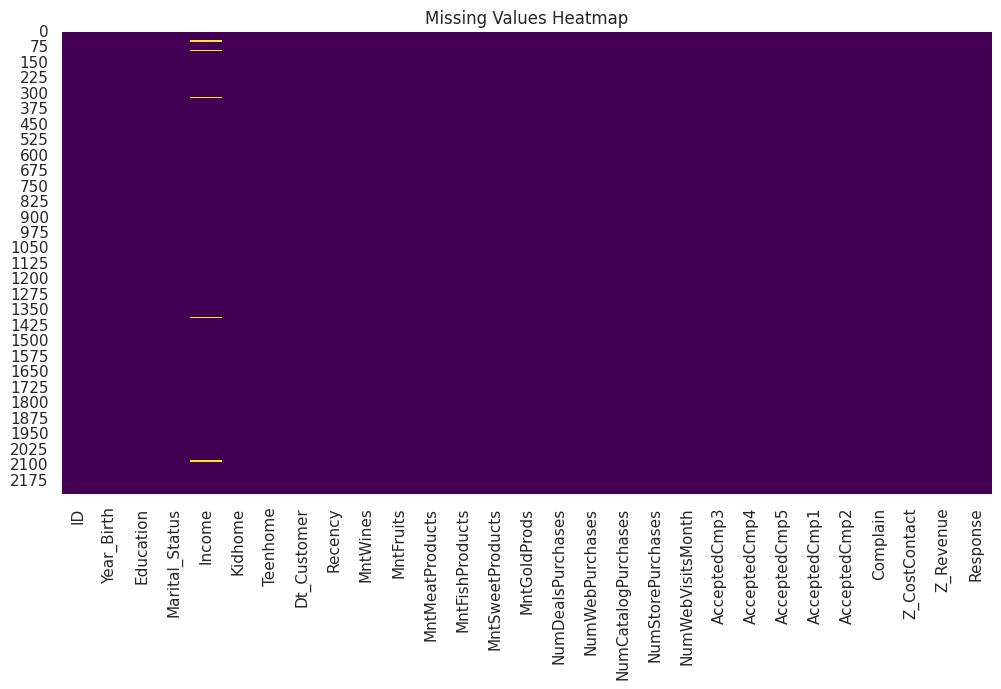


Missing Values After Imputation:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Feature Engineering Completed

Dataset After Dropping Columns:
   Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  Recency  \
0        1957  Graduation         Single  58138.0        0         0       58   
1 

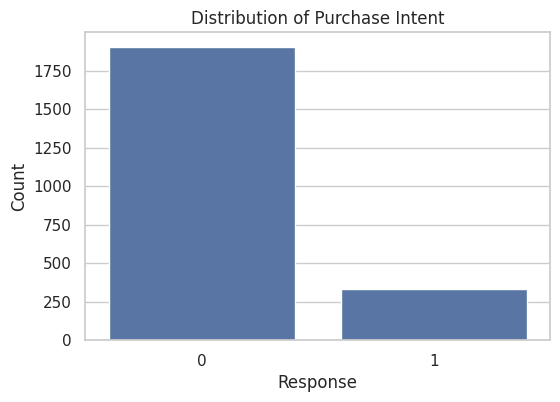

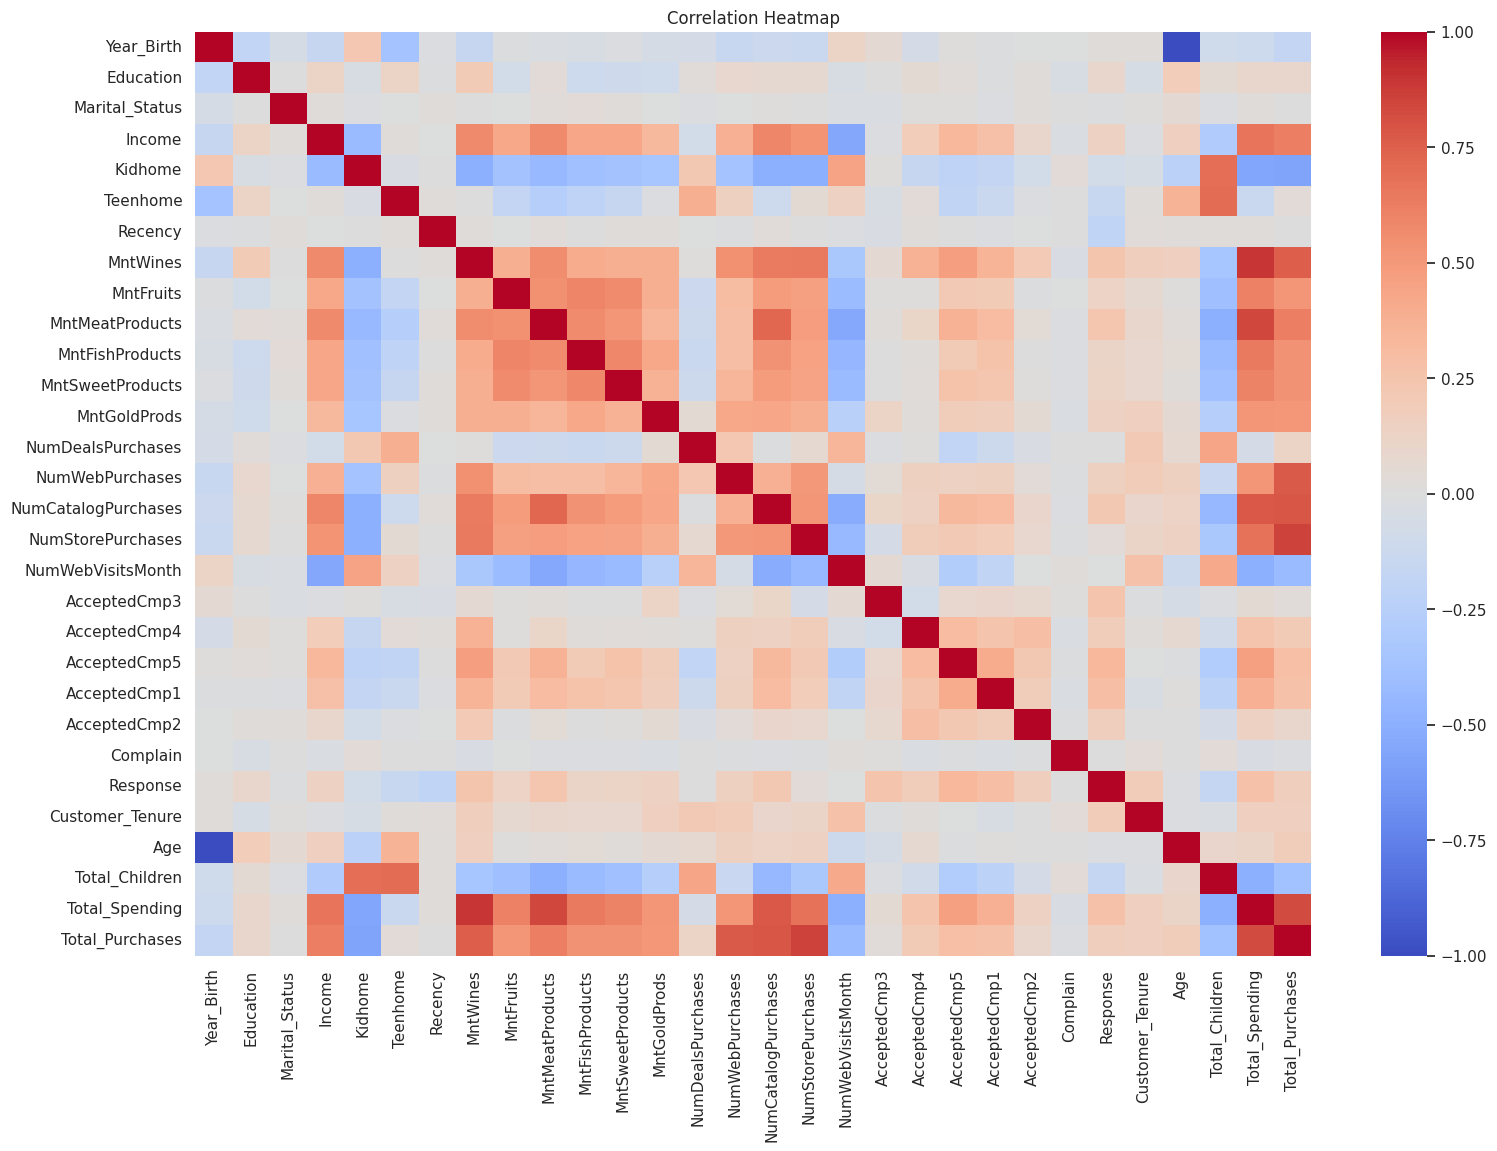

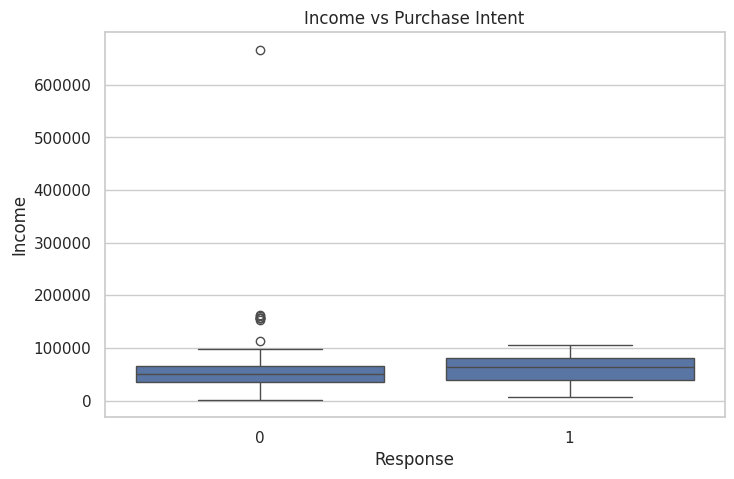

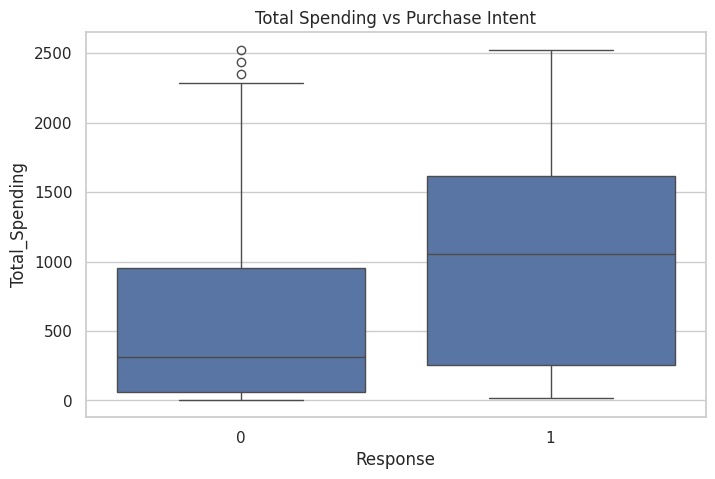

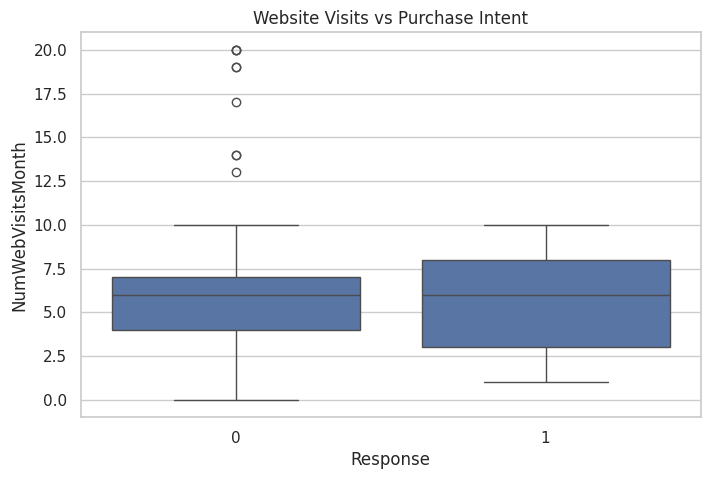


Feature Matrix Shape: (2237, 29)
Target Variable Shape: (2237,)

Training Set Shape: (2013, 29)
Testing Set Shape: (224, 29)

Feature Scaling Completed

Linear SVM Model Training Completed

Predictions Completed

================ MODEL PERFORMANCE ================

Accuracy: 0.8794642857142857
Precision: 0.7142857142857143
Recall: 0.30303030303030304
F1-Score: 0.425531914893617
ROC-AUC Score: 0.8254799301919721
Kappa Score: 0.3702623906705539

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       191
           1       0.71      0.30      0.43        33

    accuracy                           0.88       224
   macro avg       0.80      0.64      0.68       224
weighted avg       0.86      0.88      0.86       224


Performance Metrics Table:
        Metric   Value
0     Accuracy  0.8795
1    Precision  0.7143
2       Recall  0.3030
3     F1-Score  0.4255
4      ROC-AUC  0.8255
5  Kappa Score  0.3703


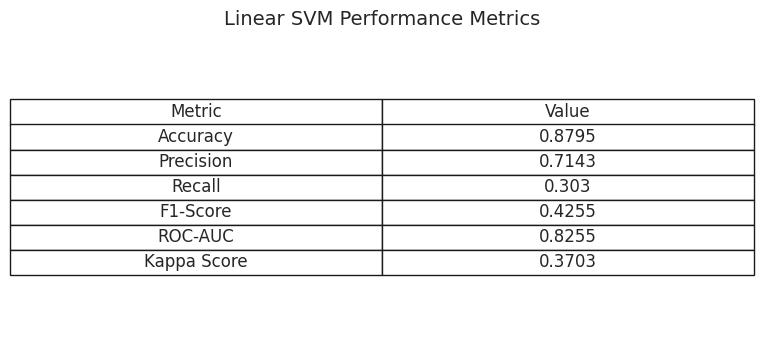


Confusion Matrix:
[[187   4]
 [ 23  10]]


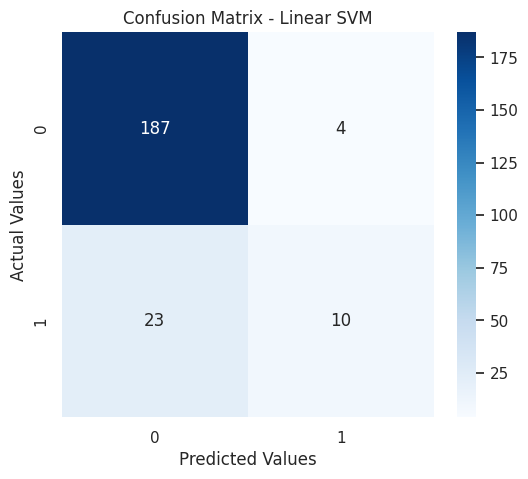

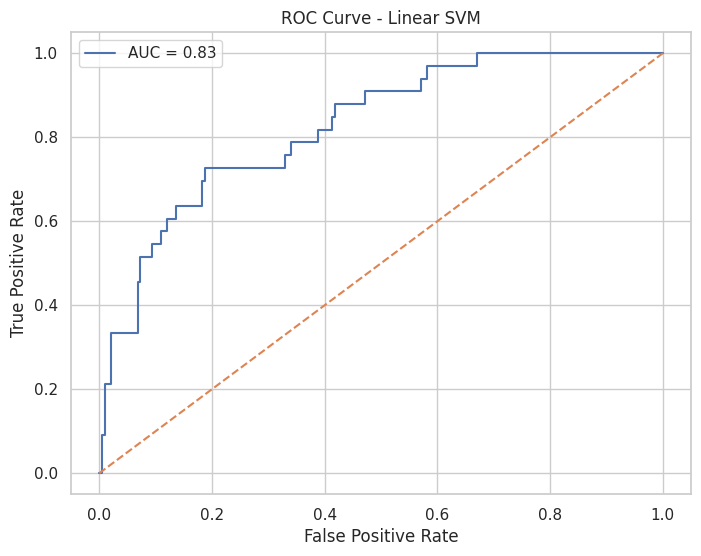


Top Important Features:
              Feature  Coefficient  Absolute_Coefficient
6             Recency    -0.462299              0.462299
24    Customer_Tenure     0.416282              0.416282
16  NumStorePurchases    -0.336865              0.336865
18       AcceptedCmp3     0.320890              0.320890
20       AcceptedCmp5     0.301776              0.301776
1           Education     0.242684              0.242684
21       AcceptedCmp1     0.230652              0.230652
9     MntMeatProducts     0.184210              0.184210
5            Teenhome    -0.176504              0.176504
19       AcceptedCmp4     0.155866              0.155866


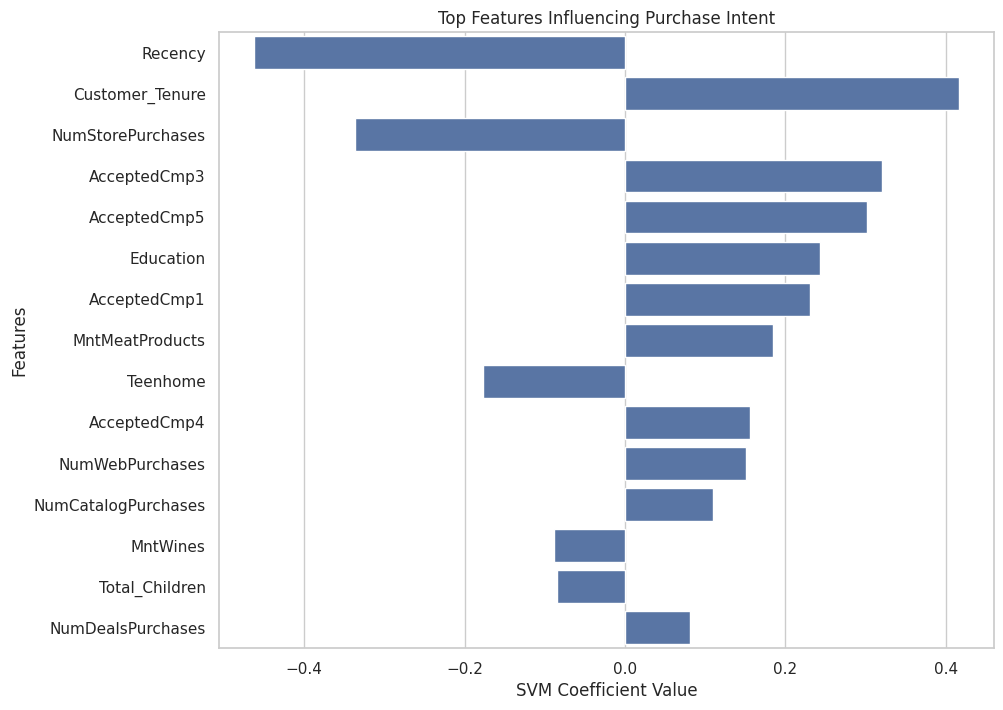

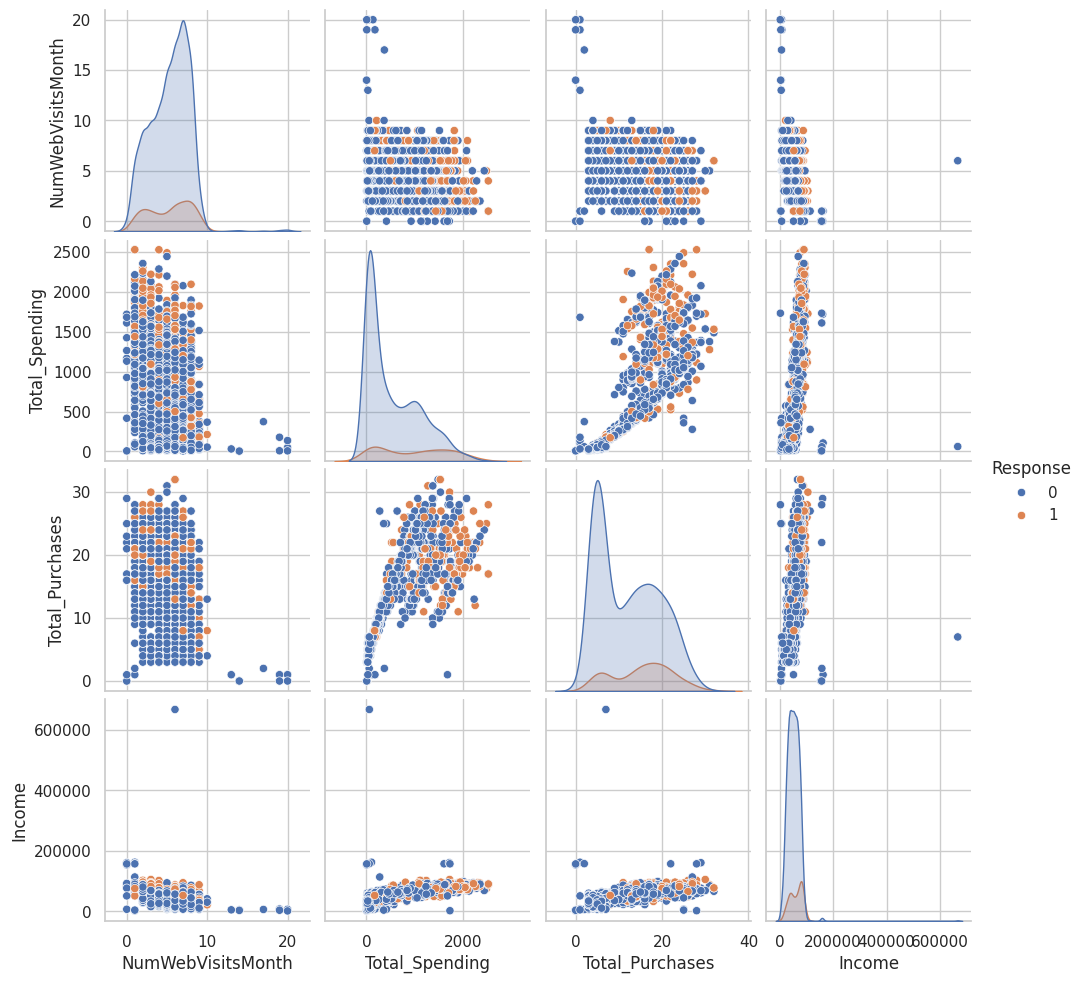


================ INTERPRETATION ================


1. Linear SVM classified customer purchase
   intent using customer engagement variables.

2. Variables such as:
   - Website visits
   - Purchases
   - Spending behavior
   significantly influenced purchase intent.

3. Accuracy, Precision, Recall,
   and F1-score evaluated classification quality.

4. ROC-AUC measured model discrimination ability.

5. Cohen’s Kappa measured agreement
   between actual and predicted classifications.

6. The model helps understand how
   customer engagement impacts purchase intent.




In [3]:
# ============================================================
# STUDYING THE RELATIONSHIP BETWEEN
# CUSTOMER ENGAGEMENT AND PURCHASE INTENT
# ============================================================

# MODEL:
# Support Vector Machine (SVM)

# KERNEL:
# Kernel 1 - Linear Kernel

# TARGET VARIABLE:
# Response

# SMOTE:
# Not Used

# TRAIN TEST SPLIT:
# 90 : 10

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Machine Learning
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    cohen_kappa_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style='whitegrid')

# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================

file_path = "/content/marketing_campaign.xlsx"

df = pd.read_excel(file_path)

print("First 5 Rows of Dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

# ============================================================
# STEP 3: DATA UNDERSTANDING
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================================================
# STEP 4: CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Missing Values Heatmap

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

# ============================================================
# STEP 5: HANDLE MISSING VALUES
# ============================================================

# Income column contains missing values
# Median imputation is suitable for skewed data

median_income = df['Income'].median()

df['Income'].fillna(
    median_income,
    inplace=True
)

print("\nMissing Values After Imputation:")

print(df.isnull().sum())

# ============================================================
# STEP 6: FEATURE ENGINEERING
# ============================================================

# Convert Date Column

df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer']
)

# Customer Tenure

latest_date = df['Dt_Customer'].max()

df['Customer_Tenure'] = (
    latest_date - df['Dt_Customer']
).dt.days

# Age Feature

current_year = 2025

df['Age'] = (
    current_year - df['Year_Birth']
)

df = df[df["Age"] <= 100 ]

# Total Children

df['Total_Children'] = (
    df['Kidhome'] + df['Teenhome']
)

# Total Spending

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Total Purchases

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

print("\nFeature Engineering Completed")

# ============================================================
# STEP 7: DROP UNNECESSARY COLUMNS
# ============================================================

columns_to_drop = [
    'ID',
    'Dt_Customer',
    'Z_CostContact',
    'Z_Revenue'
]

df.drop(
    columns=columns_to_drop,
    inplace=True
)

print("\nDataset After Dropping Columns:")
print(df.head())

# ============================================================
# STEP 8: ENCODE CATEGORICAL VARIABLES
# ============================================================

label_encoder = LabelEncoder()

categorical_columns = [
    'Education',
    'Marital_Status'
]

for col in categorical_columns:

    df[col] = label_encoder.fit_transform(
        df[col]
    )

print("\nCategorical Variables Encoded")

# ============================================================
# STEP 9: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ------------------------------------------------------------
# 1. Target Variable Distribution
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='Response',
    data=df
)

plt.title(
    'Distribution of Purchase Intent'
)

plt.xlabel('Response')

plt.ylabel('Count')

plt.show()

# ------------------------------------------------------------
# 2. Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(18,12))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

# ------------------------------------------------------------
# 3. Income vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Response',
    y='Income',
    data=df
)

plt.title('Income vs Purchase Intent')

plt.show()

# ------------------------------------------------------------
# 4. Total Spending vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Response',
    y='Total_Spending',
    data=df
)

plt.title('Total Spending vs Purchase Intent')

plt.show()

# ------------------------------------------------------------
# 5. Website Visits vs Response
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Response',
    y='NumWebVisitsMonth',
    data=df
)

plt.title('Website Visits vs Purchase Intent')

plt.show()

# ============================================================
# STEP 10: DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop(
    'Response',
    axis=1
)

y = df['Response']

print("\nFeature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)

# ============================================================
# STEP 11: TRAIN-TEST SPLIT (90:10)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)

# ============================================================
# STEP 12: FEATURE SCALING
# ============================================================

# SVM is sensitive to scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed")

# ============================================================
# STEP 13: BUILD LINEAR SVM MODEL
# ============================================================

# Kernel 1 = Linear Kernel

svm_model = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

# Train Model

svm_model.fit(
    X_train_scaled,
    y_train
)

print("\nLinear SVM Model Training Completed")

# ============================================================
# STEP 14: MAKE PREDICTIONS
# ============================================================

# Predictions

y_pred = svm_model.predict(
    X_test_scaled
)

# Probability Predictions

y_pred_prob = svm_model.predict_proba(
    X_test_scaled
)[:,1]

print("\nPredictions Completed")

# ============================================================
# STEP 15: MODEL EVALUATION
# ============================================================

# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

# Precision

precision = precision_score(
    y_test,
    y_pred
)

# Recall

recall = recall_score(
    y_test,
    y_pred
)

# F1 Score

f1 = f1_score(
    y_test,
    y_pred
)

# ROC-AUC Score

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob
)

# Cohen Kappa Score

kappa = cohen_kappa_score(
    y_test,
    y_pred
)

# Print Metrics

print("\n================ MODEL PERFORMANCE ================")

print("\nAccuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-Score:", f1)

print("ROC-AUC Score:", roc_auc)

print("Kappa Score:", kappa)

# ============================================================
# STEP 16: CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# STEP 17: PERFORMANCE METRICS TABLE
# ============================================================

metrics_table = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC',
        'Kappa Score'
    ],

    'Value': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        kappa
    ]
})

# Round Values

metrics_table['Value'] = (
    metrics_table['Value'].round(4)
)

print("\nPerformance Metrics Table:")

print(metrics_table)

# ============================================================
# STEP 18: VISUALIZE METRICS TABLE
# ============================================================

plt.figure(figsize=(8,4))

plt.axis('off')

table = plt.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(12)

table.scale(1.2, 1.5)

plt.title(
    'Linear SVM Performance Metrics',
    fontsize=14
)

plt.show()

# ============================================================
# STEP 19: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")

print(cm)

# ============================================================
# STEP 20: CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix - Linear SVM'
)

plt.xlabel('Predicted Values')

plt.ylabel('Actual Values')

plt.show()

# ============================================================
# STEP 21: ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title(
    'ROC Curve - Linear SVM'
)

plt.legend()

plt.show()

# ============================================================
# STEP 22: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': svm_model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = abs(
    feature_importance['Coefficient']
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("\nTop Important Features:")

print(feature_importance.head(10))

# ============================================================
# STEP 23: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,8))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title(
    'Top Features Influencing Purchase Intent'
)

plt.xlabel('SVM Coefficient Value')

plt.ylabel('Features')

plt.show()

# ============================================================
# STEP 24: RELATIONSHIP VISUALIZATION
# ============================================================

selected_features = [
    'NumWebVisitsMonth',
    'Total_Spending',
    'Total_Purchases',
    'Income',
    'Response'
]

sns.pairplot(
    df[selected_features],
    hue='Response'
)

plt.show()

# ============================================================
# STEP 25: INTERPRETATION
# ============================================================

print("\n================ INTERPRETATION ================")

print("""

1. Linear SVM classified customer purchase
   intent using customer engagement variables.

2. Variables such as:
   - Website visits
   - Purchases
   - Spending behavior
   significantly influenced purchase intent.

3. Accuracy, Precision, Recall,
   and F1-score evaluated classification quality.

4. ROC-AUC measured model discrimination ability.

5. Cohen’s Kappa measured agreement
   between actual and predicted classifications.

6. The model helps understand how
   customer engagement impacts purchase intent.

""")